<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%204/%20Assignment_4_Epley_Win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
import missingno as msno
!pip install category_encoders
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


# Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

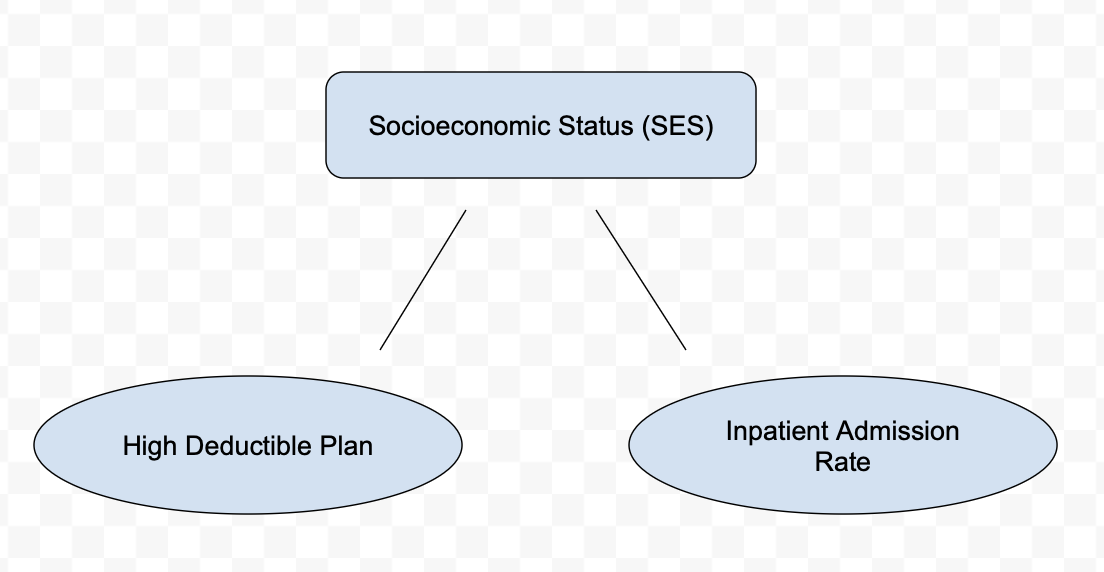

The positive relationship between high-deductible insurance plans and inpatient admission rates is likely being driven by an omitted variable, such as socioeconomic status (SES). Patients with lower income are more likely to choose high-deductible plans because they have lower monthly premiums, but they are also more likely to delay preventative care due to cost. This can lead to more serious health issues over time, increasing the likelihood of inpatient admissions.

Because SES affects both insurance type and admission rates, leaving it out of the regression creates omitted variable bias. The model incorrectly attributes some of the effect of SES to the insurance variable, which makes it look like high-deductible plans are causing higher admission rates. In reality, the relationship is being driven by underlying differences in patient income, not a direct causal effect.

# Step 1.2: The Variance Inflation Factor (VIF) Audit

In [2]:
vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")

In [3]:
features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
X = vitals[features].dropna()

In [4]:
X_const = sm.add_constant(X)

In [5]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

print(vif_data)

        Feature          VIF
0         const  3369.565806
1     Weight_kg    57.428058
2     Height_cm    28.419446
3           BMI    16.981232
4   Systolic_BP     4.219406
5  Diastolic_BP     4.219820


In [6]:
features = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]
X = vitals[features].dropna()
X_const = sm.add_constant(X)
vif_data_new = pd.DataFrame()
vif_data_new["Feature"] = X_const.columns
vif_data_new["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print(vif_data_new)

        Feature         VIF
0         const  321.090128
1     Weight_kg    3.763969
2     Height_cm    3.763812
3   Systolic_BP    4.219406
4  Diastolic_BP    4.219820


The initial VIF results show severe multicollinearity, with Weight_kg (57.43), Height_cm (28.42), and BMI (16.98) all exceeding the threshold of 10. This is expected since BMI is calculated from weight and height, making it redundant. To resolve this, BMI was removed from the model. After recalculating the VIF values, all remaining variables fall below 10, indicating that multicollinearity has been successfully reduced and the feature set is now stable.

# Step 2.1: The Architecture of Missingness

In [7]:
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")

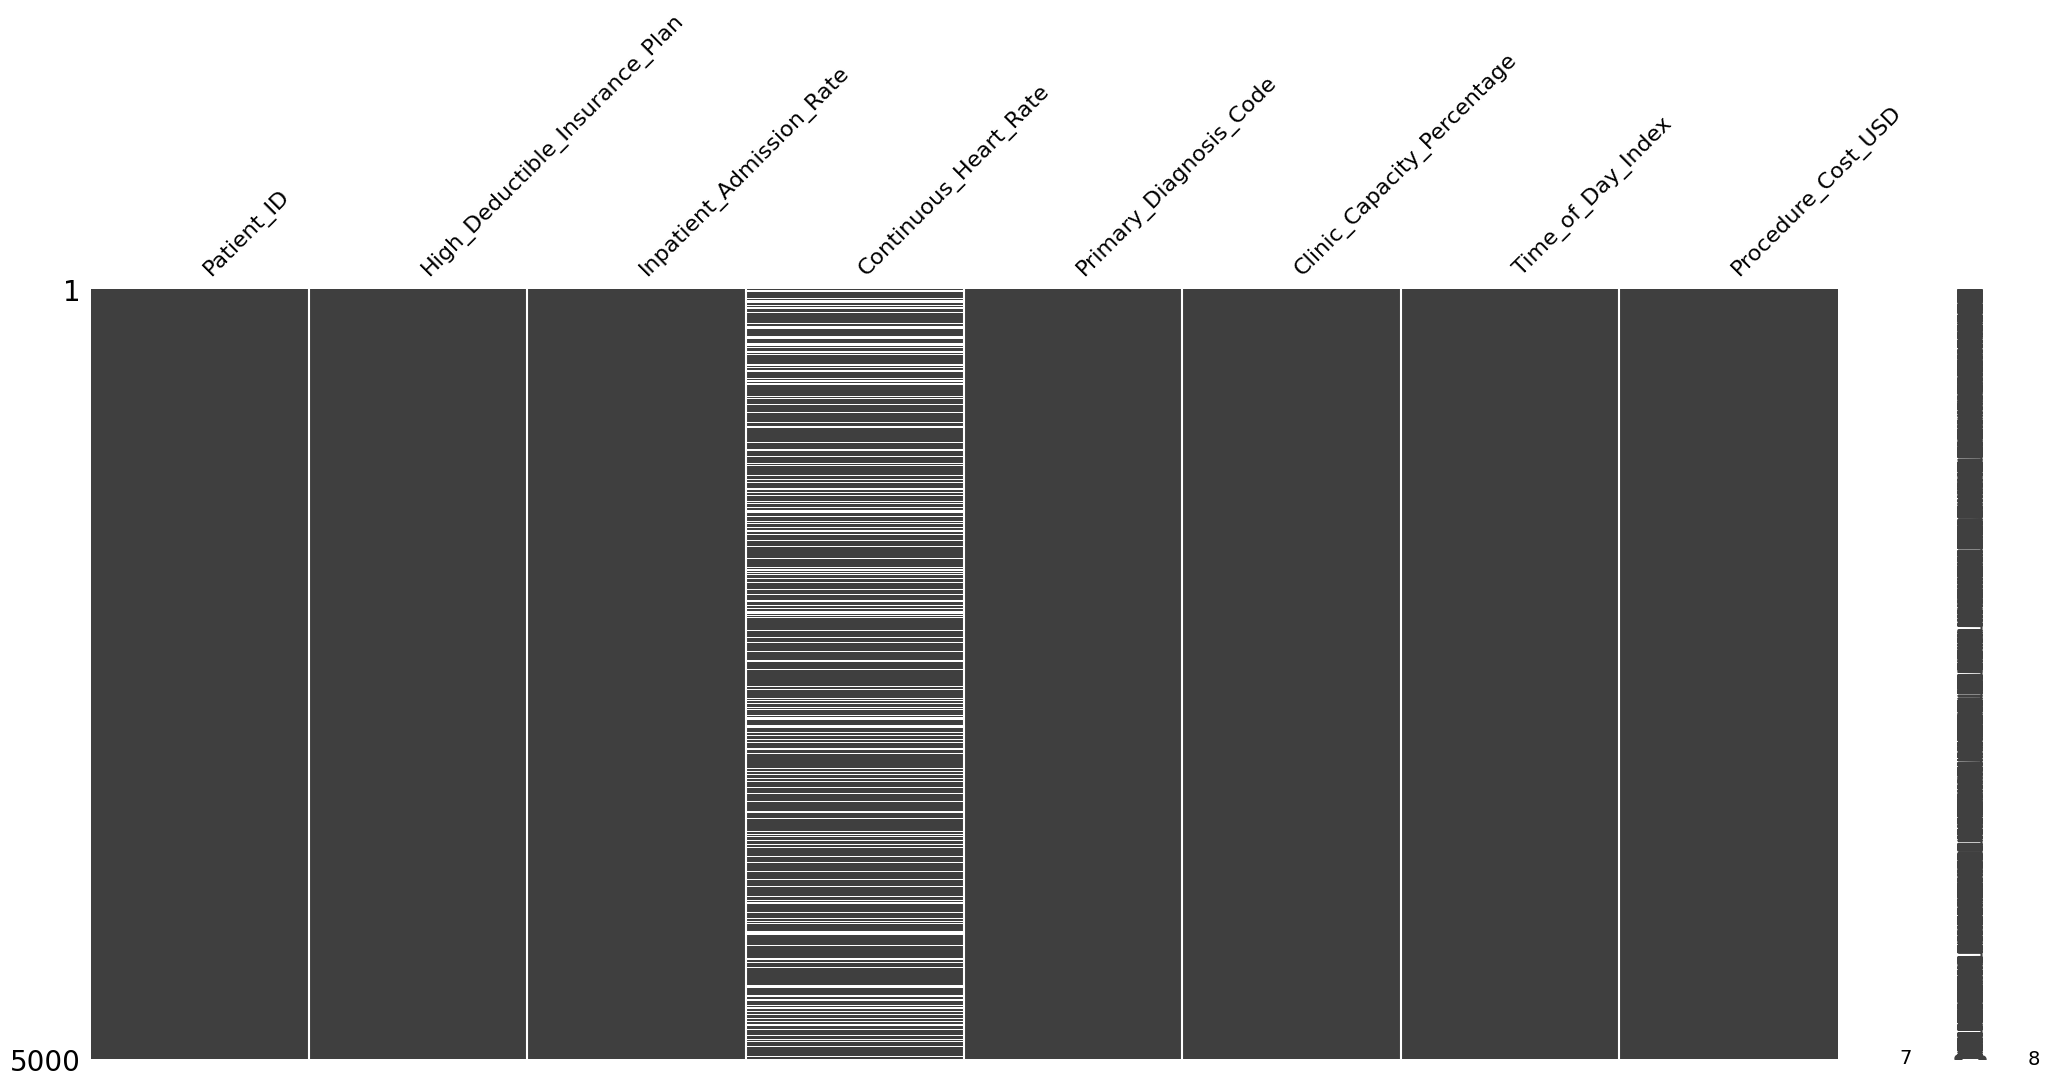

In [8]:
msno.matrix(telemetry)
plt.show()

The missingness matrix shows that most variables are fully observed, except for Continuous_Heart_Rate, which contains significant gaps across many observations. This pattern suggests that the missing data is not random. Based on the scenario, where low-income patients may avoid transmitting data due to cost, this missingness is best classified as Missing Not At Random (MNAR). The probability of missing data depends on an unobserved factor (income), which directly affects whether the data is recorded. Because of this, simple techniques like mean imputation would introduce bias by masking systematic differences in the data.

# Step 2.2: Escaping the Dummy Variable Trap

Using one-hot encoding on a categorical variable with 850 unique values creates 850 dummy variables. Since each observation must belong to exactly one category, the sum of all dummy variables for a given row equals 1. When an intercept term is included in the regression, this creates perfect multicollinearity because one dummy variable can be written as a linear combination of the others. As a result, the design matrix becomes singular and cannot be inverted, which prevents the Ordinary Least Squares estimator from computing valid coefficients.

# Step 2.3: Target Encoding Implementation

In [9]:
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

telemetry["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    telemetry["Primary_Diagnosis_Code"],
    telemetry["Procedure_Cost_USD"]
)
print(telemetry[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head())

  Primary_Diagnosis_Code  Target_Encoded_Diagnosis
0                J86.381               1707.697108
1                M29.789               1792.303198
2                E49.618               1730.334968
3                E66.244               1725.060944
4                J45.553               1801.821085


# Step 3.1: OLS Optimization via Patsy Formulas

In [10]:
df = pd.merge(vitals, telemetry, on="Patient_ID")

In [11]:
df = df.dropna()

In [12]:
model = smf.ols(
    formula="""
    Procedure_Cost_USD ~
    Target_Encoded_Diagnosis +
    Clinic_Capacity_Percentage +
    Time_of_Day_Index +
    Weight_kg + Height_cm +
    Systolic_BP + Diastolic_BP
    """,
    data=df
).fit()

In [13]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     183.9
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          3.87e-235
Time:                        17:28:47   Log-Likelihood:                -27366.
No. Observations:                3786   AIC:                         5.475e+04
Df Residuals:                    3778   BIC:                         5.480e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

# Step 3.2: Financial Loss Quantification (RMSE)

In [14]:
predictions = model.fittedvalues

model_rmse = rmse(df["Procedure_Cost_USD"], predictions)

print("RMSE:", model_rmse)

RMSE: 333.33867982171273



The RMSE of the model is approximately \$333, meaning that the model's predictions deviate from the true procedure costs by an average of \$333. Given that a typical MRI costs around \$1,200, this represents a substantial error margin of over 25%. Such a large prediction error creates significant financial and operational risks. The model could systematically overcharge patients, leading to regulatory violations and reputational damage, or undercharge, resulting in revenue losses for the hospital. This level of inaccuracy makes the model unsafe for deployment in a real-world dynamic pricing system.

# Step 3.3: Residual Diagnostics for Heteroscedasticity

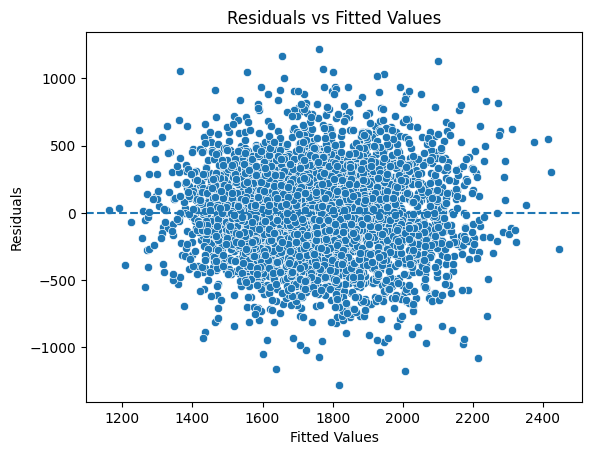

In [15]:
residuals = model.resid
fitted = model.fittedvalues

sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

The residual plot shows that the errors are fairly evenly distributed across the range of fitted values, without a clear funnel or widening pattern. This suggests that the variance of the residuals is relatively constant, meaning there is no strong evidence of heteroscedasticity. As a result, the model appears to satisfy the homoscedasticity assumption, indicating that its predictions are relatively stable across different pricing levels.

# 4.1

**Prime Prompt:**

Persona:
You are a senior econometrician and machine learning engineer with expertise in statistical diagnostics and model validation using Python and statsmodels.

Role:
Your role is to generate a clean, well-documented Python script that performs advanced diagnostic testing on an already fitted Ordinary Least Squares (OLS) regression model.

Instructions:
Using the statsmodels library, write Python code to perform White’s Lagrange Multiplier Test for heteroscedasticity on an existing OLS model object named model. Extract the residuals and exogenous variables from the fitted model and apply the statsmodels.stats.diagnostic.het_white function. The script should print the test statistic, p-value, and clearly label each output. Ensure the code is concise, readable, and executable without modification.

Meaning:
This test is being conducted to evaluate whether the OLS model violates the assumption of homoscedasticity. Detecting heteroscedasticity is critical because it can lead to inefficient estimates and invalid standard errors, which undermine the reliability of inference and decision-making in a healthcare pricing context.

Evaluation:
The output should include a clear interpretation of the results. If the p-value is below a standard significance level (e.g., 0.05), conclude that heteroscedasticity is present. If not, conclude that there is no strong evidence of heteroscedasticity. The explanation should be concise and written in a way that a data analyst could understand.

In [16]:
"""
White's Lagrange Multiplier Test for Heteroscedasticity
========================================================
Context : Healthcare pricing OLS model diagnostics
Purpose : Detect violations of the homoscedasticity assumption
Requires: statsmodels, numpy
"""

import numpy as np
from statsmodels.stats.diagnostic import het_white

# ── 1. Extract components from the fitted OLS model ──────────────────────────
residuals  = model.resid          # OLS residuals (ê)
exog_vars  = model.model.exog     # Design matrix X (includes constant column)

# ── 2. Run White's LM Test ───────────────────────────────────────────────────
lm_stat, lm_pval, f_stat, f_pval = het_white(residuals, exog_vars)

# ── 3. Display results ───────────────────────────────────────────────────────
SIGNIFICANCE_LEVEL = 0.05

print("=" * 55)
print("     White's LM Test for Heteroscedasticity")
print("=" * 55)
print(f"  LM Test Statistic : {lm_stat:.4f}")
print(f"  LM p-value        : {lm_pval:.4f}")
print(f"  F-Statistic       : {f_stat:.4f}")
print(f"  F p-value         : {f_pval:.4f}")
print("-" * 55)

# ── 4. Interpret and conclude ─────────────────────────────────────────────────
if lm_pval < SIGNIFICANCE_LEVEL:
    conclusion = (
        f"  RESULT  : Heteroscedasticity DETECTED (p = {lm_pval:.4f})\n"
        f"  MEANING : The variance of the residuals is NOT constant\n"
        f"            across observations. OLS standard errors are\n"
        f"            unreliable — consider using HC-robust standard\n"
        f"            errors (cov_type='HC3') or a WLS/GLS approach\n"
        f"            before drawing inference on healthcare pricing."
    )
else:
    conclusion = (
        f"  RESULT  : No strong evidence of heteroscedasticity\n"
        f"            (p = {lm_pval:.4f})\n"
        f"  MEANING : Residual variance appears reasonably constant.\n"
        f"            The homoscedasticity assumption holds at the\n"
        f"            {SIGNIFICANCE_LEVEL} significance level. Standard\n"
        f"            OLS inference remains valid for this model."
    )

print(conclusion)
print("=" * 55)

     White's LM Test for Heteroscedasticity
  LM Test Statistic : 159.2136
  LM p-value        : 0.0000
  F-Statistic       : 4.7035
  F p-value         : 0.0000
-------------------------------------------------------
  RESULT  : Heteroscedasticity DETECTED (p = 0.0000)
  MEANING : The variance of the residuals is NOT constant
            across observations. OLS standard errors are
            unreliable — consider using HC-robust standard
            errors (cov_type='HC3') or a WLS/GLS approach
            before drawing inference on healthcare pricing.
